# D2C Customer Intelligence & Retention Prioritization

## Part 2: Advanced RFM Segmentation & Customer Behavior Analysis

### Objective

This notebook builds a business-oriented customer intelligence framework using RFM analysis, churn behavior, engagement activity, and support interactions to identify valuable customers, retention risks, and intervention opportunities.

The analysis focuses on:

- leakage-safe RFM calculation,
- churn-aware segmentation,
- customer-value prioritization,
- engagement decline detection,
- support dissatisfaction analysis,
- and retention-focused business intelligence.

---

**Author:** Prateek Parmar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_style("whitegrid")

In [2]:
# Dataset Loading

data_path = r"C:\D2C_Customer_Churn_Capstone\d2c churn data package\\"

customers = pd.read_csv(data_path + "customers.csv")
try:
    orders = pd.read_csv("orders_clean.csv")
    print("Loaded orders_clean.csv")

except FileNotFoundError:
    orders = pd.read_csv(data_path + "orders.csv")
    print("WARNING: orders_clean.csv not found, falling back to orders.csv")

AMT_COL = "gross_amount_capped" if "gross_amount_capped" in orders.columns else "gross_amount"
print(f"Using monetary column: {AMT_COL}")

support_tickets = pd.read_csv(data_path + "support_tickets.csv")
web_events = pd.read_csv(data_path + "web_events_snapshot.csv")
churn_labels = pd.read_csv(data_path + "churn_labels.csv")
intervention_history = pd.read_csv(data_path + "intervention_history.csv")

print("Datasets loaded successfully")

Loaded orders_clean.csv
Using monetary column: gross_amount_capped
Datasets loaded successfully


In [3]:
print("Customers Shape:", customers.shape)
print("Orders Shape:", orders.shape)
print("Support Tickets Shape:", support_tickets.shape)
print("Web Events Shape:", web_events.shape)
print("Churn Labels Shape:", churn_labels.shape)
print("Intervention History Shape:", intervention_history.shape)

Customers Shape: (2400, 9)
Orders Shape: (8128, 11)
Support Tickets Shape: (1921, 8)
Web Events Shape: (2400, 10)
Churn Labels Shape: (2400, 4)
Intervention History Shape: (2400, 5)


In [4]:
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


# Snapshot Integrity & Leakage Prevention

In [5]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
churn_labels['snapshot_date'] = pd.to_datetime(churn_labels['snapshot_date'])

print("Date conversion completed")

Date conversion completed


In [6]:
SNAPSHOT_DATE = "2025-09-30"

orders_pre_snapshot = orders[
    orders["order_date"] <= SNAPSHOT_DATE
]

post_snapshot_orders = orders[
    orders["order_date"] > SNAPSHOT_DATE
]

print("Original orders shape:", orders.shape)
print("Pre-snapshot orders shape:", orders_pre_snapshot.shape)
print("Post-snapshot orders shape:", post_snapshot_orders.shape)

Original orders shape: (8128, 11)
Pre-snapshot orders shape: (8128, 11)
Post-snapshot orders shape: (0, 11)


In [7]:
post_snapshot_orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating,gross_amount_capped


# RFM Metric Creation

In [8]:
reference_date = orders_pre_snapshot['order_date'].max()

print("Reference Date:", reference_date)

Reference Date: 2025-09-30 00:00:00


In [9]:
rfm = orders_pre_snapshot.groupby('customer_id').agg({
    'order_date': lambda x: (reference_date - x.max()).days,
    'order_id': 'count',
    AMT_COL: 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST00001,107,6,2955.57
1,CUST00002,40,1,581.00
2,CUST00003,171,1,649.98
3,CUST00004,131,1,1604.04
4,CUST00005,38,4,2550.91


In [10]:
rfm.describe()

,Recency,Frequency,Monetary
count,2400.000000,2400.000000,2400.000000
mean,87.375833,3.386667,2505.698077
std,80.137473,2.380725,1942.663250
min,0.000000,1.000000,149.000000
25%,25.000000,1.000000,954.525000
50%,66.000000,3.000000,2010.710000
75%,129.000000,5.000000,3554.992500
max,562.000000,16.000000,13721.270000


# RFM Distribution Analysis

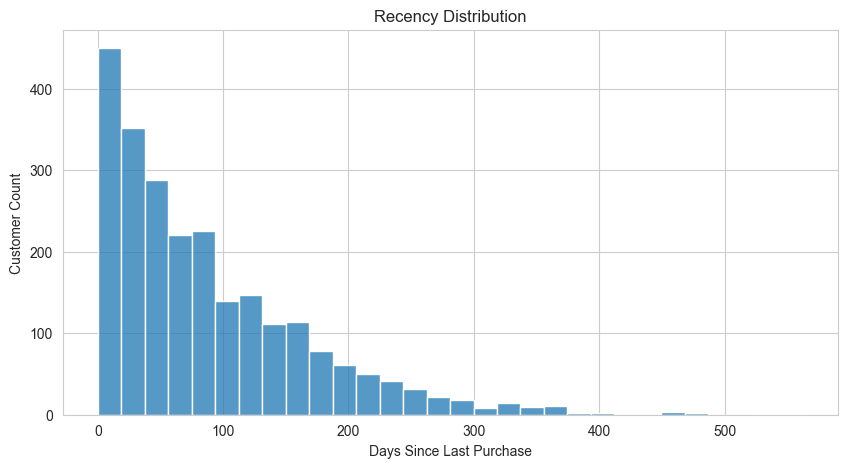

In [11]:
#Recency Distribution

plt.figure(figsize=(10,5))

sns.histplot(rfm['Recency'], bins=30)

plt.title("Recency Distribution")

plt.xlabel("Days Since Last Purchase")

plt.ylabel("Customer Count")

plt.show()

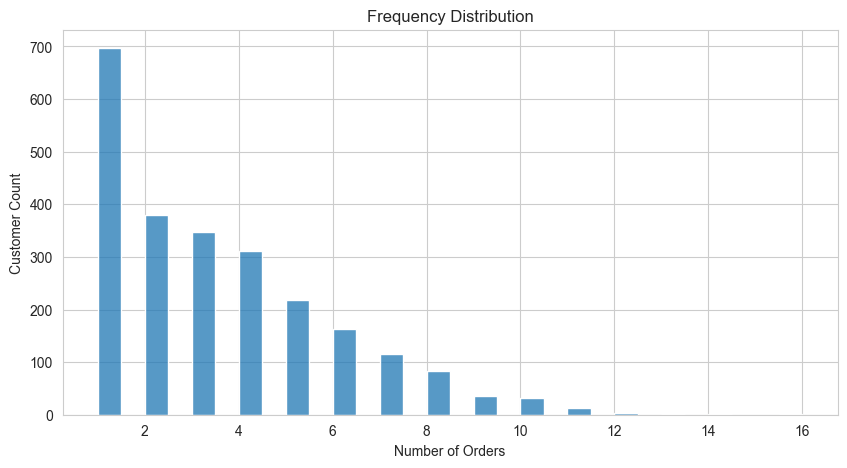

In [12]:
#Frequency Distribution

plt.figure(figsize=(10,5))

sns.histplot(rfm['Frequency'], bins=30)

plt.title("Frequency Distribution")

plt.xlabel("Number of Orders")

plt.ylabel("Customer Count")

plt.show()

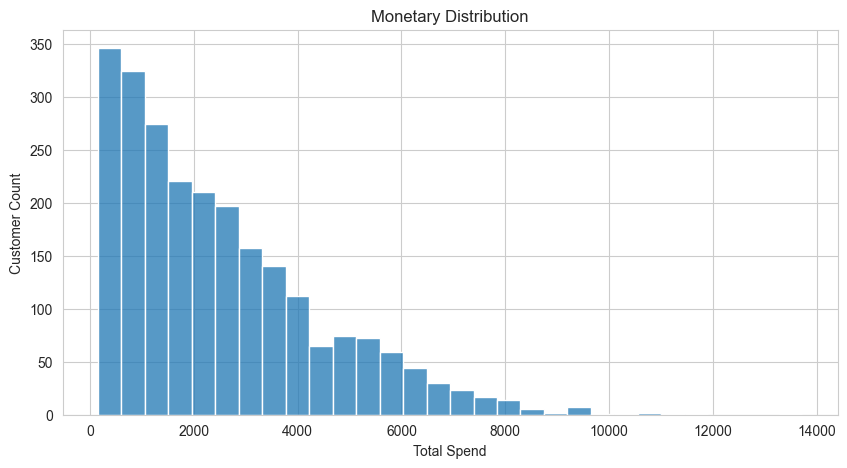

In [13]:
#Monetary Distribution

plt.figure(figsize=(10,5))

sns.histplot(rfm['Monetary'], bins=30)

plt.title("Monetary Distribution")

plt.xlabel("Total Spend")

plt.ylabel("Customer Count")

plt.show()

# RFM Scoring

In [14]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [15]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,CUST00001,107,6,2955.57,2,5,4,254
1,CUST00002,40,1,581.00,4,1,1,411
2,CUST00003,171,1,649.98,1,1,1,111
3,CUST00004,131,1,1604.04,2,1,3,213
4,CUST00005,38,4,2550.91,4,3,4,434


# Business-Oriented Customer Segmentation

In [16]:
def segment_customer(row):

    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    # Champions
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Loyal Customers
    elif f >= 4 and m >= 3:
        return "Loyal Customers"

    # Big Spenders
    elif m >= 5 and f <= 3:
        return "Big Spenders"

    # At Risk
    elif r <= 2 and f <= 2:
        return "At Risk"

    # Recent Customers
    elif r >= 4 and f <= 2:
        return "Recent Customers"

    # Regular Customers
    else:
        return "Regular Customers"


In [17]:
rfm['Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers
2,CUST00003,171,1,649.98,1,1,1,111,At Risk
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk
4,CUST00005,38,4,2550.91,4,3,4,434,Regular Customers


# Behaviour Overlay — 'High-Value but Unhappy'
---
RFM alone cannot express sentiment. We add a non-RFM overlay flag that marks Champions / Loyal / Big Spenders whose support sentiment is negative. These are the canonical High-Value but Unhappy archetype from the brief — kept as an overlay so RFM segments stay clean and auditable.



In [44]:
# Behaviour overlay is added AFTER support merge (see 'Support Experience Integration').
# We define the helper here and apply it once sentiment_score is available on rfm_support.
def behaviour_flag(row):
    if row['Segment'] in ['Champions', 'Loyal Customers', 'Big Spenders'] \
       and pd.notna(row.get('sentiment_score')) and row['sentiment_score'] < 0:
        return 'Unhappy High-Value'
    return 'Normal'


# Segment Business Analysis

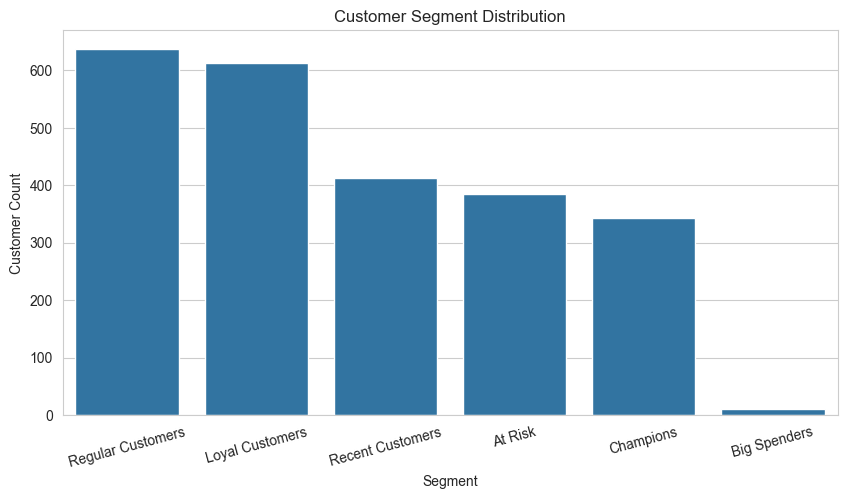

In [18]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Segment Distribution")

plt.xlabel("Segment")
plt.ylabel("Customer Count")

plt.xticks(rotation=15)

plt.show()

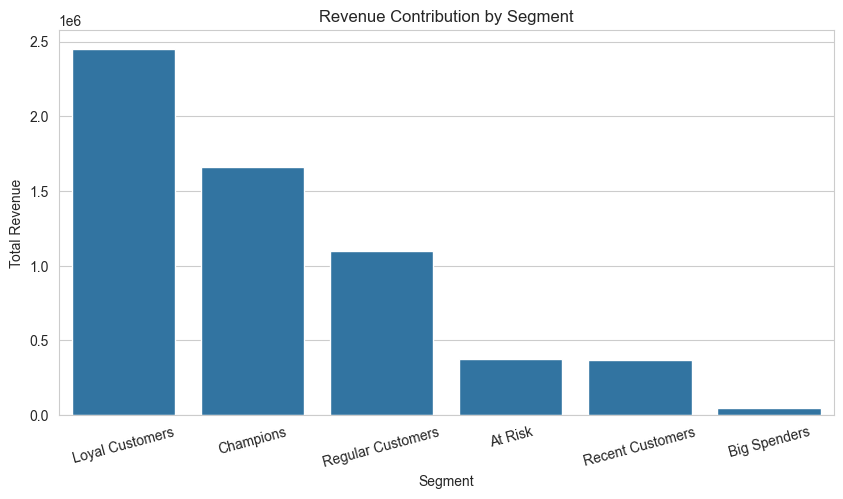

In [19]:
#Revenue Contribution by Segment

segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values
)

plt.title("Revenue Contribution by Segment")

plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=15)

plt.show()

In [20]:
#Average Monetary Value

segment_avg_spend = (
    rfm.groupby('Segment')['Monetary']
    .mean()
    .sort_values(ascending=False)
)

segment_avg_spend

Segment
Champions            4840.107015
Big Spenders         4529.317709
Loyal Customers      4010.018054
Regular Customers    1726.568903
At Risk               982.820529
Recent Customers      899.541486
Name: Monetary, dtype: float64

# Segment vs Churn Analysis

In [21]:
rfm_churn = rfm.merge(
    churn_labels[['customer_id', 'churn_next_60d']],
    on='customer_id',
    how='left'
)

rfm_churn.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_next_60d
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers,1
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers,0
2,CUST00003,171,1,649.98,1,1,1,111,At Risk,1
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk,1
4,CUST00005,38,4,2550.91,4,3,4,434,Regular Customers,0


In [22]:
segment_churn = (
    rfm_churn.groupby('Segment')['churn_next_60d']
    .mean()
    .sort_values(ascending=False)
)

segment_churn

Segment
At Risk              0.859375
Loyal Customers      0.555556
Big Spenders         0.545455
Regular Customers    0.504702
Recent Customers     0.225728
Champions            0.104956
Name: churn_next_60d, dtype: float64

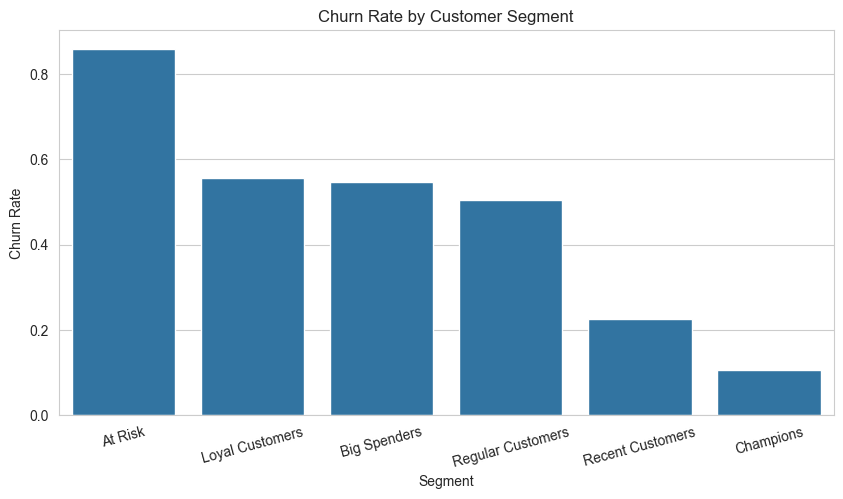

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_churn.index,
    y=segment_churn.values
)

plt.title("Churn Rate by Customer Segment")

plt.xlabel("Segment")
plt.ylabel("Churn Rate")

plt.xticks(rotation=15)

plt.show()

In [24]:
high_value_risk = rfm_churn[
    (rfm_churn['Segment'].isin(['Champions', 'Big Spenders'])) &
    (rfm_churn['churn_next_60d'] == 1)
]

high_value_risk.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_next_60d
19,CUST00020,368,3,4120.6808,1,3,5,135,Big Spenders,1
50,CUST00051,210,4,4444.3000,1,3,5,135,Big Spenders,1
109,CUST00110,35,6,3922.0700,4,5,4,454,Champions,1
183,CUST00184,14,5,5072.8500,5,4,5,545,Champions,1
187,CUST00188,29,7,5810.1700,4,5,5,455,Champions,1


# Digital Engagement Integration

In [25]:
rfm_engagement = rfm.merge(
    web_events,
    on='customer_id',
    how='left'
)

rfm_engagement.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,171,1,649.98,1,1,1,111,At Risk,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,38,4,2550.91,4,3,4,434,Regular Customers,2025-09-30,18,95,4,1,1,3,1,9


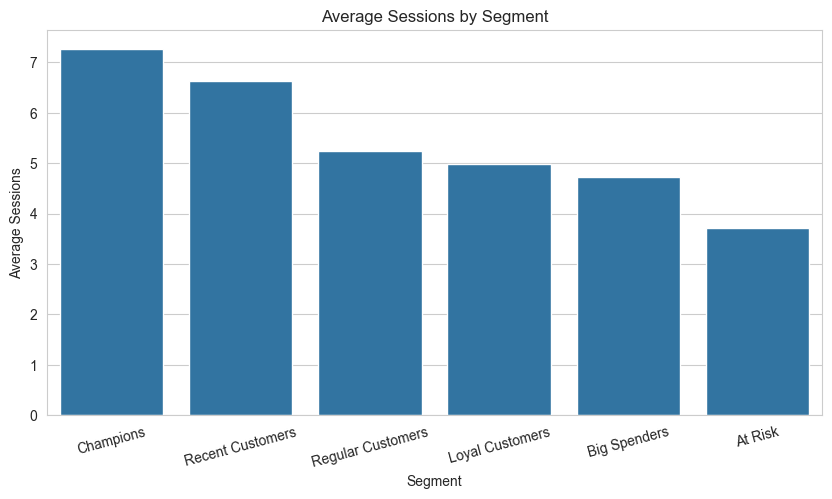

In [26]:
segment_sessions = (
    rfm_engagement.groupby('Segment')['sessions_30d']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_sessions.index,
    y=segment_sessions.values
)

plt.title("Average Sessions by Segment")

plt.xlabel("Segment")
plt.ylabel("Average Sessions")

plt.xticks(rotation=15)

plt.show()

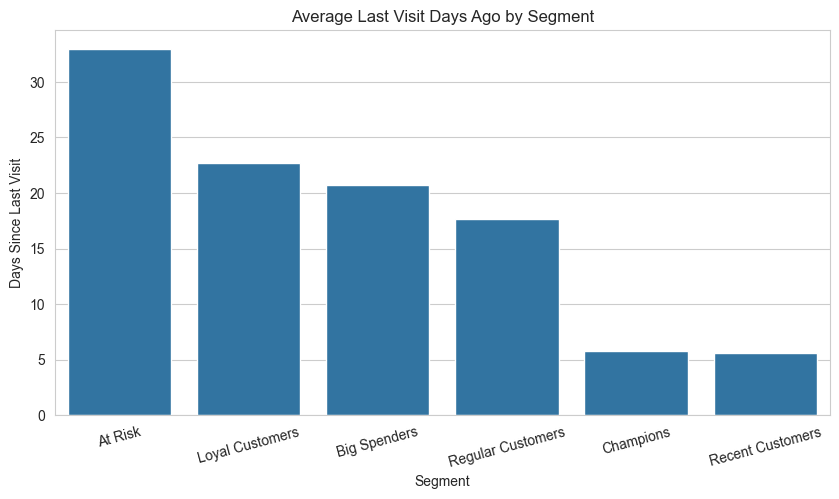

In [27]:
segment_last_visit = (
    rfm_engagement.groupby('Segment')['last_visit_days_ago']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_last_visit.index,
    y=segment_last_visit.values
)

plt.title("Average Last Visit Days Ago by Segment")

plt.xlabel("Segment")
plt.ylabel("Days Since Last Visit")

plt.xticks(rotation=15)

plt.show()

In [28]:
silent_risk_customers = rfm_engagement[
    (rfm_engagement['Segment'].isin(['Champions', 'Big Spenders'])) &
    (rfm_engagement['sessions_30d'] < rfm_engagement['sessions_30d'].median())
]

silent_risk_customers.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
19,CUST00020,368,3,4120.6808,1,3,5,135,Big Spenders,2025-09-30,0,0,0,0,0,0,0,60
28,CUST00029,18,8,5252.9000,5,5,5,555,Champions,2025-09-30,1,6,0,0,0,0,0,0
96,CUST00097,1,7,4703.4600,5,5,5,555,Champions,2025-09-30,0,0,0,0,0,0,0,0
109,CUST00110,35,6,3922.0700,4,5,4,454,Champions,2025-09-30,4,15,1,1,0,0,0,8
111,CUST00112,0,8,5576.2500,5,5,5,555,Champions,2025-09-30,4,15,1,1,0,0,0,0


# Support Experience Integration

In [29]:
support_summary = (
    support_tickets.groupby('customer_id')
    .agg({
        'sentiment_score': 'mean',
        'reopened': 'sum',
        'resolution_hours': 'mean'
    })
    .reset_index()
)

support_summary.head()

,customer_id,sentiment_score,reopened,resolution_hours
0,CUST00001,0.14,0,4.35
1,CUST00002,0.00,0,1.00
2,CUST00005,-1.00,0,37.70
3,CUST00006,-0.68,1,17.60
4,CUST00008,0.08,0,6.00


In [30]:
rfm_support = rfm.merge(
    support_summary,
    on='customer_id',
    how='left'
)

rfm_support.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,sentiment_score,reopened,resolution_hours
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers,0.14,0.0,4.35
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers,0.00,0.0,1.00
2,CUST00003,171,1,649.98,1,1,1,111,At Risk,NaN,NaN,NaN
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk,NaN,NaN,NaN
4,CUST00005,38,4,2550.91,4,3,4,434,Regular Customers,-1.00,0.0,37.70


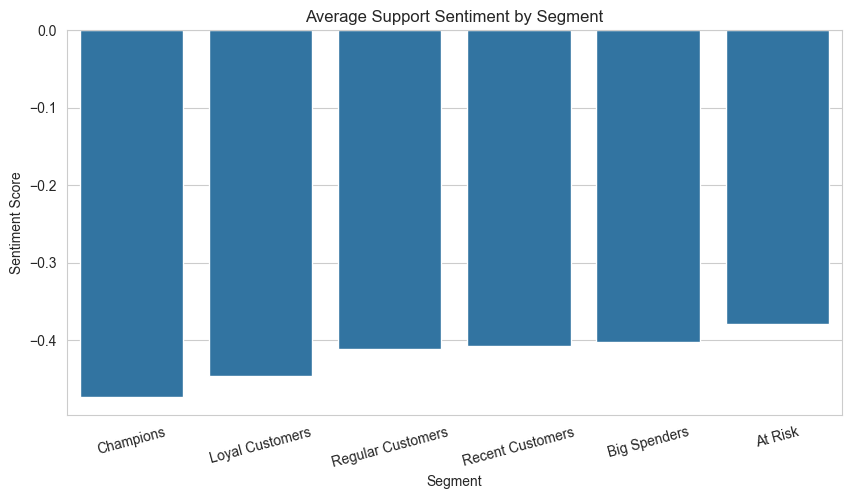

In [31]:
segment_sentiment = (
    rfm_support.groupby('Segment')['sentiment_score']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_sentiment.index,
    y=segment_sentiment.values
)

plt.title("Average Support Sentiment by Segment")

plt.xlabel("Segment")
plt.ylabel("Sentiment Score")

plt.xticks(rotation=15)

plt.show()

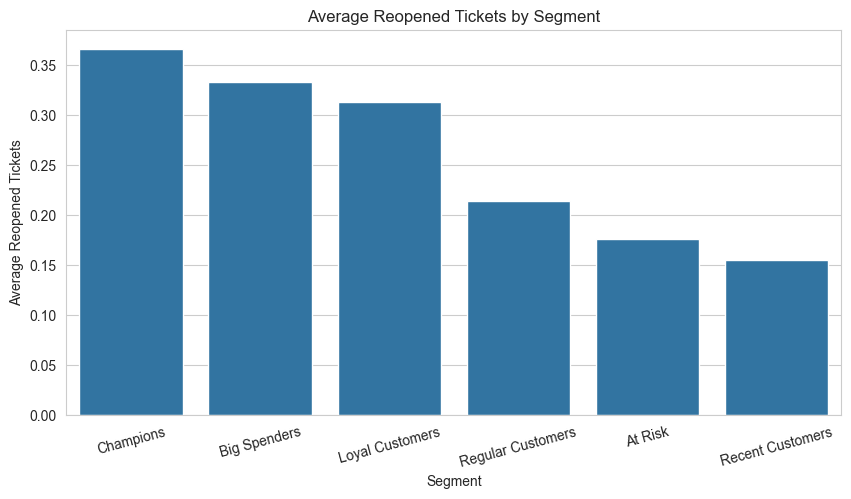

In [32]:
segment_reopened = (
    rfm_support.groupby('Segment')['reopened']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_reopened.index,
    y=segment_reopened.values
)

plt.title("Average Reopened Tickets by Segment")

plt.xlabel("Segment")
plt.ylabel("Average Reopened Tickets")

plt.xticks(rotation=15)

plt.show()

In [33]:
dissatisfied_high_value = rfm_support[
    (rfm_support['Segment'].isin(['Champions', 'Big Spenders'])) &
    (rfm_support['sentiment_score'] < 0)
]

dissatisfied_high_value.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,sentiment_score,reopened,resolution_hours
19,CUST00020,368,3,4120.6808,1,3,5,135,Big Spenders,-0.9500,0.0,28.900
29,CUST00030,5,6,3435.5900,5,5,4,554,Champions,-0.4150,0.0,27.650
50,CUST00051,210,4,4444.3000,1,3,5,135,Big Spenders,-0.3850,0.0,42.200
52,CUST00053,25,4,4192.5900,4,3,5,435,Big Spenders,-0.5650,1.0,47.150
74,CUST00075,3,9,6791.6100,5,5,5,555,Champions,-0.3525,1.0,27.125


# Retention Prioritization Framework

In [34]:
def retention_priority(row):

    # Highest priority
    if (
        row['Segment'] in ['Champions', 'Big Spenders']
        and row['churn_next_60d'] == 1
    ):
        return "Critical Retention"

    # Silent disengagement
    elif (
        row['Segment'] in ['Champions', 'Loyal Customers']
        and row['last_visit_days_ago'] > 20
    ):
        return "Engagement Recovery"

    # Dissatisfied valuable customers
    elif (
        row['Segment'] in ['Champions', 'Big Spenders']
        and row['sentiment_score'] < 0
    ):
        return "Service Recovery"

    # General at-risk users
    elif row['Segment'] == 'At Risk':
        return "Win-Back Campaign"

    # Recent users
    elif row['Segment'] == 'Recent Customers':
        return "Onboarding & Nurture"

    else:
        return "Regular Engagement"

In [35]:
customer_intelligence = rfm.merge(
    churn_labels[['customer_id', 'churn_next_60d']],
    on='customer_id',
    how='left'
)

customer_intelligence = customer_intelligence.merge(
    web_events,
    on='customer_id',
    how='left'
)

customer_intelligence = customer_intelligence.merge(
    support_summary,
    on='customer_id',
    how='left'
)

customer_intelligence.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_next_60d,...,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,sentiment_score,reopened,resolution_hours
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers,1,...,4,0,0,0,2,0,20,0.14,0.0,4.35
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers,0,...,31,4,2,3,0,0,0,0.00,0.0,1.00
2,CUST00003,171,1,649.98,1,1,1,111,At Risk,1,...,3,0,0,0,0,0,26,NaN,NaN,NaN
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk,1,...,6,0,0,0,0,0,14,NaN,NaN,NaN
4,CUST00005,38,4,2550.91,4,3,4,434,Regular Customers,0,...,95,4,1,1,3,1,9,-1.00,0.0,37.70


In [36]:
customer_intelligence['Retention_Priority'] = (
    customer_intelligence.apply(
        retention_priority,
        axis=1
    )
)

customer_intelligence.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_next_60d,...,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,sentiment_score,reopened,resolution_hours,Retention_Priority
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers,1,...,0,0,0,2,0,20,0.14,0.0,4.35,Regular Engagement
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers,0,...,4,2,3,0,0,0,0.00,0.0,1.00,Onboarding & Nurture
2,CUST00003,171,1,649.98,1,1,1,111,At Risk,1,...,0,0,0,0,0,26,NaN,NaN,NaN,Win-Back Campaign
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk,1,...,0,0,0,0,0,14,NaN,NaN,NaN,Win-Back Campaign
4,CUST00005,38,4,2550.91,4,3,4,434,Regular Customers,0,...,4,1,1,3,1,9,-1.00,0.0,37.70,Regular Engagement


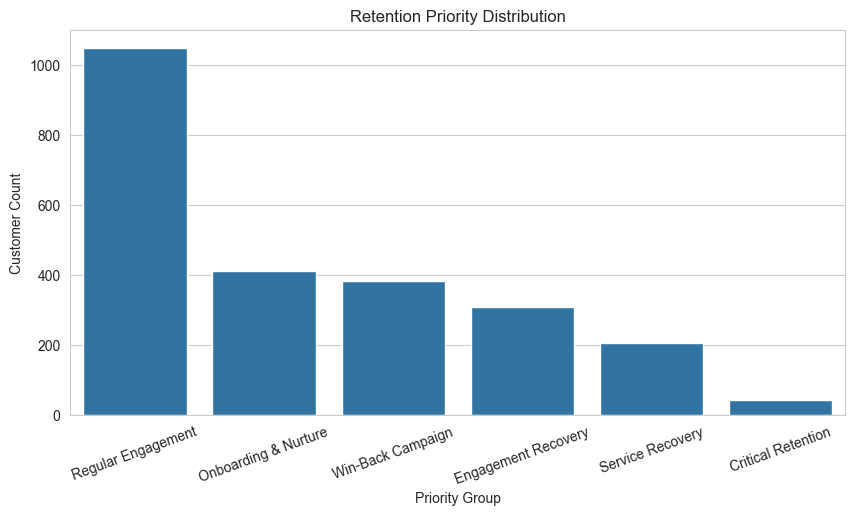

In [37]:
priority_counts = (
    customer_intelligence['Retention_Priority']
    .value_counts()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=priority_counts.index,
    y=priority_counts.values
)

plt.title("Retention Priority Distribution")

plt.xlabel("Priority Group")
plt.ylabel("Customer Count")

plt.xticks(rotation=20)

plt.show()

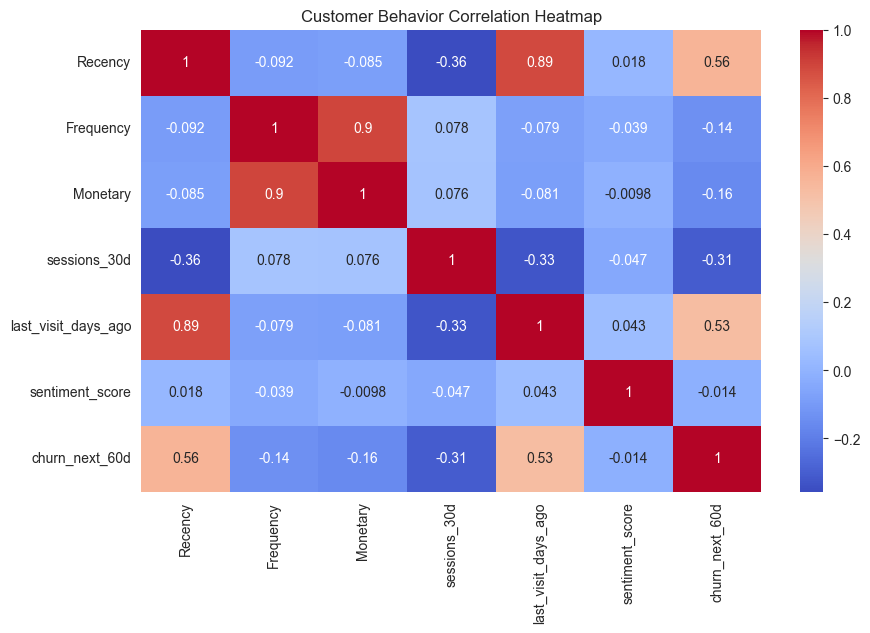

In [38]:
corr_cols = [
    'Recency',
    'Frequency',
    'Monetary',
    'sessions_30d',
    'last_visit_days_ago',
    'sentiment_score',
    'churn_next_60d'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    customer_intelligence[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Customer Behavior Correlation Heatmap")

plt.show()

# Manual Review: real CUST IDs per archetype

In [39]:
ci_full = customer_intelligence.copy()
ci_full['churn_flag'] = ci_full['churn_next_60d'].fillna(0).astype(int)
manual_cases = []

def grab(df, case, reason, n=2):
    for _, r in df.head(n).iterrows():
        manual_cases.append({
            'case': case, 'customer_id': r['customer_id'],
            'Segment': r['Segment'], 'Recency': r['Recency'],
            'Frequency': r['Frequency'], 'Monetary': round(r['Monetary'], 2),
            'sessions_30d': r.get('sessions_30d'),
            'last_visit_days_ago': r.get('last_visit_days_ago'),
            'sentiment_score': r.get('sentiment_score'),
            'churn_next_60d': r['churn_flag'],
            'reason': reason})

# C1: High-value but disengaged
c1 = ci_full[(ci_full['Segment'].isin(['Champions','Loyal Customers','Big Spenders']))
             & (ci_full['sessions_30d'].fillna(0) <= 1)
             & (ci_full['last_visit_days_ago'].fillna(0) >= 30)].nlargest(2,'Monetary')
grab(c1, 'C1 High-value disengaged', 'High Monetary, near-zero sessions, long inactivity')

# C2: Loyal but unhappy
c2 = ci_full[(ci_full['Segment'].isin(['Champions','Loyal Customers']))
             & (ci_full['sentiment_score'].fillna(0) < -0.3)].nlargest(2,'Monetary')
grab(c2, 'C2 Loyal but unhappy', 'Strong purchase history, negative support sentiment')

# C3: Recent big-spender, short history
c3 = ci_full[(ci_full['Segment']=='Big Spenders') & (ci_full['Frequency']<=2)
             & (ci_full['Recency']<=15)].nlargest(2,'Monetary')
grab(c3, 'C3 Recent big-spender', 'High spend on very few orders — may not repeat')

# C4: Churned Champions
c4 = ci_full[(ci_full['Segment']=='Champions') & (ci_full['churn_flag']==1)].nlargest(2,'Monetary')
grab(c4, 'C4 Churned Champion', 'Top RFM yet labelled churn — early-warning failure')

# C5: Low monetary, high engagement
c5 = ci_full[(ci_full['Monetary'] < ci_full['Monetary'].quantile(0.3))
             & (ci_full['sessions_30d'].fillna(0) >= ci_full['sessions_30d'].quantile(0.9))]\
             .nlargest(2,'sessions_30d')
grab(c5, 'C5 Low-spend high-engagement', 'Future conversion candidate undervalued by RFM')

# C6: Conflicting signals
c6 = ci_full[(ci_full['churn_flag']==1) & (ci_full['sentiment_score'].fillna(0) < 0)
             & (ci_full['Monetary'] > ci_full['Monetary'].median())].nlargest(2,'Monetary')
grab(c6, 'C6 Conflicting signals', 'High M + churn=1 + negative sentiment all together')

manual_df = pd.DataFrame(manual_cases)
manual_df.to_csv('manual_review_cases.csv', index=False)
print('Total manual-review customers:', len(manual_df))
manual_df

Total manual-review customers: 10


,case,customer_id,Segment,Recency,Frequency,Monetary,sessions_30d,last_visit_days_ago,sentiment_score,churn_next_60d,reason
0,C1 High-value disengaged,CUST01714,Loyal Customers,132,8,7387.29,0,36,-0.420000,1,"High Monetary, near-zero sessions, long inacti..."
1,C1 High-value disengaged,CUST00993,Loyal Customers,164,7,6785.33,1,39,0.240000,1,"High Monetary, near-zero sessions, long inacti..."
2,C2 Loyal but unhappy,CUST02154,Loyal Customers,106,16,11777.27,10,24,-0.626667,0,"Strong purchase history, negative support sent..."
3,C2 Loyal but unhappy,CUST00991,Champions,41,11,11377.01,9,16,-0.745000,0,"Strong purchase history, negative support sent..."
4,C4 Churned Champion,CUST02072,Champions,35,11,7176.07,4,1,-0.500000,1,Top RFM yet labelled churn — early-warning fai...
5,C4 Churned Champion,CUST00524,Champions,11,10,7161.96,10,11,0.045000,1,Top RFM yet labelled churn — early-warning fai...
6,C5 Low-spend high-engagement,CUST00566,Recent Customers,22,1,657.76,25,3,NaN,0,Future conversion candidate undervalued by RFM
7,C5 Low-spend high-engagement,CUST00659,Recent Customers,16,1,883.27,21,0,NaN,0,Future conversion candidate undervalued by RFM
8,C6 Conflicting signals,CUST00397,Loyal Customers,79,11,9647.73,3,22,-0.357500,1,High M + churn=1 + negative sentiment all toge...
9,C6 Conflicting signals,CUST00702,Loyal Customers,77,6,8044.75,2,16,-0.570000,1,High M + churn=1 + negative sentiment all toge...


In [40]:
rfm.to_csv(
    "segments.csv",
    index=False
)

print("segments.csv exported successfully")


segments.csv exported successfully


In [41]:
manual_review_cases = customer_intelligence[
    (
        (customer_intelligence['Segment'] == 'Champions') &
        (customer_intelligence['sessions_30d'] < 5)
    )
    |
    (
        (customer_intelligence['sentiment_score'] < -0.5)
    )
]

manual_review_cases.head(10)

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_next_60d,...,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,sentiment_score,reopened,resolution_hours,Retention_Priority
4,CUST00005,38,4,2550.9100,4,3,4,434,Regular Customers,0,...,4,1,1,3,1,9,-1.00,0.0,37.70,Regular Engagement
5,CUST00006,51,5,3770.1600,3,4,4,344,Loyal Customers,0,...,1,0,1,0,0,1,-0.68,1.0,17.60,Regular Engagement
12,CUST00013,61,3,1754.4400,3,3,3,333,Regular Customers,0,...,1,0,0,2,0,21,-1.00,0.0,74.60,Regular Engagement
19,CUST00020,368,3,4120.6808,1,3,5,135,Big Spenders,1,...,0,0,0,0,0,60,-0.95,0.0,28.90,Critical Retention
20,CUST00021,77,2,1059.3000,3,2,2,322,Regular Customers,1,...,1,1,0,2,0,18,-0.85,0.0,20.10,Regular Engagement
25,CUST00026,72,3,3561.3900,3,3,4,334,Regular Customers,0,...,3,3,0,1,0,26,-0.63,0.0,20.00,Regular Engagement
28,CUST00029,18,8,5252.9000,5,5,5,555,Champions,0,...,0,0,0,0,0,0,NaN,NaN,NaN,Regular Engagement
32,CUST00033,12,4,2128.0900,5,3,3,533,Regular Customers,0,...,2,2,1,3,0,7,-0.94,0.0,36.35,Regular Engagement
40,CUST00041,54,4,1911.8600,3,3,3,333,Regular Customers,1,...,1,1,0,4,2,22,-1.00,0.0,53.00,Regular Engagement
43,CUST00044,72,3,2724.0900,3,3,4,334,Regular Customers,0,...,2,1,1,4,2,10,-1.00,1.0,46.70,Regular Engagement


# Budget-aware retention prioritization

In [42]:
ci = customer_intelligence.copy()
ci['churn_flag'] = ci['churn_next_60d'].fillna(0).astype(int)
ci['retention_value'] = ci['Monetary'] * ci['churn_flag']

INTERVENTION_COST = 150  # INR per customer contact (configurable)
ci['expected_net_value'] = ci['retention_value'] - INTERVENTION_COST

budget_top = (ci[ci['expected_net_value'] > 0]
              .sort_values('expected_net_value', ascending=False)
              .head(200))

print('Customers worth contacting (net-positive):', (ci['expected_net_value'] > 0).sum())
print('Top-200 expected revenue saved: INR', round(budget_top['retention_value'].sum(), 0))

budget_top.to_csv('retention_action_list_top200.csv', index=False)
ci.to_csv('customer_intelligence_segments.csv', index=False)
print('Saved: retention_action_list_top200.csv, customer_intelligence_segments.csv')

budget_top[['customer_id','Segment','Retention_Priority','Monetary','churn_flag','expected_net_value']].head(20)


Customers worth contacting (net-positive): 1125
Top-200 expected revenue saved: INR 1016202.0
Saved: retention_action_list_top200.csv, customer_intelligence_segments.csv


,customer_id,Segment,Retention_Priority,Monetary,churn_flag,expected_net_value
396,CUST00397,Loyal Customers,Engagement Recovery,9647.7300,1,9497.7300
1948,CUST01949,Loyal Customers,Engagement Recovery,9603.3100,1,9453.3100
825,CUST00826,Loyal Customers,Engagement Recovery,8171.4000,1,8021.4000
701,CUST00702,Loyal Customers,Regular Engagement,8044.7500,1,7894.7500
1546,CUST01547,Loyal Customers,Regular Engagement,7802.0500,1,7652.0500
1110,CUST01111,Loyal Customers,Regular Engagement,7703.5500,1,7553.5500
1091,CUST01092,Loyal Customers,Regular Engagement,7414.1208,1,7264.1208
1713,CUST01714,Loyal Customers,Engagement Recovery,7387.2900,1,7237.2900
870,CUST00871,Loyal Customers,Engagement Recovery,7332.9600,1,7182.9600
1383,CUST01384,Loyal Customers,Engagement Recovery,7203.9808,1,7053.9808


In [43]:
ih = intervention_history.merge(
    churn_labels[['customer_id','churn_next_60d']], on='customer_id', how='left')

campaign_perf = (ih.groupby('last_campaign_received')
                   .agg(customers=('customer_id','nunique'),
                        churn_rate=('churn_next_60d','mean'))
                   .sort_values('churn_rate'))
print('Churn rate by past campaign (lower = campaign helped):')
print(campaign_perf)

bucket_perf = (ih.groupby('manual_priority_bucket')
                 .agg(customers=('customer_id','nunique'),
                      churn_rate=('churn_next_60d','mean')))
print('\nChurn rate by manual priority bucket:')
print(bucket_perf)


Churn rate by past campaign (lower = campaign helped):
                        customers  churn_rate
last_campaign_received                       
none                          507    0.451677
welcome_offer                 453    0.452539
free_shipping                 469    0.462687
bundle_discount               473    0.469345
new_launch                    498    0.510040

Churn rate by manual priority bucket:
                        customers  churn_rate
manual_priority_bucket                       
high                         1163    0.747206
low                           488    0.100410
medium                        749    0.279039
